# TCSPC Simulation and Fitting
(Code from https://nbviewer.jupyter.org/github/tritemio/notebooks/blob/master/Lifetime_decay_fit.ipynb; copied here so that I can examine and understand the code)



In [1]:
# Modules
import numpy as np
import scipy
import scipy.stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.pyplot import hist, plot

import lmfit
from lmfit import Parameters, report_fit

## TCSPC Data Simulation
- TCSPC data is simulated by an exponentially-modified Gaussian distribution, which is the analytical solution of the convolution of a gaussian curve and an exponential

$$f(x; \mu, \sigma, \lambda) = \frac{\lambda}{2}e^{\frac{\lambda}{2}(2 \mu + \lambda \sigma^2 - 2 x)} erfc \Bigg( \frac{\mu + \lambda \sigma^2 - x}{\sqrt{2} \sigma} \Bigg)$$

- this function is then used to compute the instrument response function with $\sigma =  33 \ ps$ and $\lambda = 100 \ ps$

In [2]:
# TCSPC parameters
time_step_s = (60e-9/4096)
time_step_ns = time_step_s * 1e9
time_nbins = 2048

time_idx = np.arange(time_nbins)
time_ns = time_idx * time_step_ns

In [3]:
def exgauss(x, mu, sig, tau):
    lam = 1.0 / tau
    out = 0.5*lam * np.exp(0.5*lam * (2*mu + lam*(sig**2) - 2*x)) * scipy.special.erfc((mu + lam*(sig**2) - x) / (np.sqrt(2)*sig))
    return(out)

In [41]:
irf_sig = 0.1
irf_mu = 7*irf_sig
irf_lam = 0.5

x_irf = np.arange(0, (irf_lam * 15 + irf_mu) / time_step_ns)
p_irf = exgauss(x_irf, irf_mu/time_step_ns, irf_sig/time_step_ns, irf_lam/time_step_ns)

# the now generated IRFs PDF is used to discretize the simulated data
irf = scipy.stats.rv_discrete(name = 'irf', values = (x_irf, p_irf))
x_irf.size


560

47.786666666666676


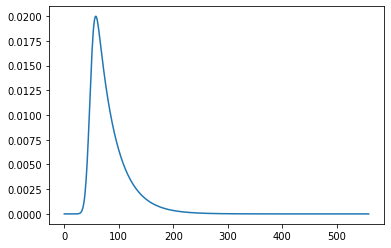

In [42]:
plot(x_irf, p_irf)
#plt.yscale('log')
print(irf_mu/time_step_ns)

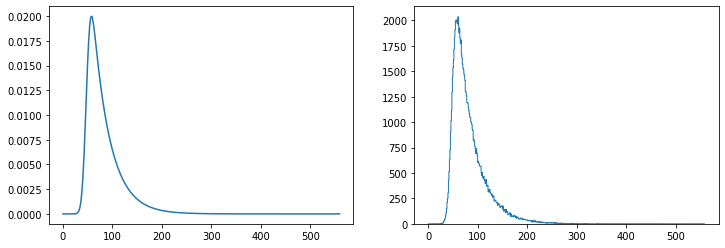

In [43]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ax[0].plot(x_irf, irf.pmf(x_irf))
ax[1].hist(irf.rvs(size = 100000), bins = x_irf, histtype = 'step')
plt.show()

In [22]:
assert (p_irf == irf.pmf(x_irf)).all()

## Generating Nanotimes

In [29]:
num_samples = int(5e5)
tau = 2e-9
baseline_fraction = 0.03
offset = 2e-9

sample_decay = np.random.exponential(scale = tau/time_step_s, size = num_samples) + offset/time_step_s
sample_decay += irf.rvs(size = num_samples)
sample_baseline = np.random.randint(low = 0, high = time_nbins, size = int(baseline_fraction*num_samples))

sample_tot = np.hstack((sample_decay, sample_baseline))
decay_hist, bins = np.histogram(sample_tot, bins = np.arange(time_nbins + 1))

baseline_true = baseline_fraction*num_samples / time_nbins
print(baseline_true)

7.32421875


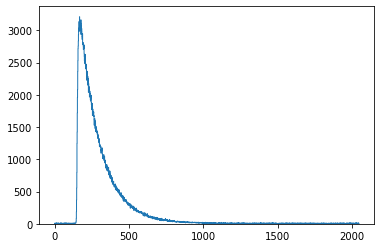

In [31]:
hist_sim_decay, _, _ = hist(sample_tot, bins = np.arange(time_nbins + 1), histtype = 'step')
#plt.yscale('log')
plt.show()

## Model Function for Curve Fittin

In [41]:
def model(x, tau, ampl, baseline, offset, irf_pdf = irf.pmf(x_irf)):
    
    y = np.zeros(x.size)
    pos_range = (x - offset) >= 0
    y[pos_range] = ampl*np.exp(-(x[pos_range] - offset)/ tau)
    z = np.convolve(y, irf_pdf, mode = 'same')
    z += baseline
    return(z)

def residuals(params, x, y, weights):
    
    tau = params['tau'].value
    baseline = params['baseline'].value
    offset = params['offset'].value
    ampl = params['ampl'].value
    out = y - model(x, tau, ampl, baseline, offset) * weights
    return(out)

def plot_fit(time, ydata, params, yscale = 'log', zoom_origin = False):
    
    plot(time, ydata, '.')
    plot(time, model(time, **{k: v.value for k, v in params.item()}), color = 'r', lw = 2.5, alpha = 0.75)
    
    if(yscale == 'log'):
        plt.yscale('log')
        plt.ylim(1)
    if(zoom_origin):
        dt = time[1] - time[0]
        t0 = params['offset'] - 50 * dt
        plt.xlim(t0 - 50*dt, t0 + 50*dt)

### MLE Approach

$$p(k) = \frac{\lambda^k}{\Gamma(k+1)} e^{- \lambda}$$

$$log \ p (k) = k \ log \lambda - log \ \Gamma(k + 1) - \lambda$$

$$\lambda_i = \lambda(t_i, \tau, A, t_0, b)$$

In [42]:
def loglike(params, x, ydata):
    tau, baseline, offset, ampl = params
    ymodel = model(x, tau, ampl, baseline, offset)
    out = ymodel - ydata*np.log(ymodel).sum()
    return(out)

def from_params(params):
    out = [params[k].value for k in ('tau', 'baseline', 'offset', 'ampl')]
    return(out)

def to_params(p, params):
    for v, k in zip(p, ('tau', 'baseline', 'offset', 'ampl')):
        params[k].value = v
    return params

In [43]:
# Poisson weights


weights[decay_hist == 0] = 1./np.sqrt(baseline_true)
(decay_hist == 0).any()



/home/agbp/.local/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in true_divide
  


True

In [51]:
# Fitting the decay


params = Parameters()
params.add('tau', value=2.8)
params.add('baseline', value=5)
params.add('offset', value=2.814, vary=False)
params.add('ampl', value=700)



In [52]:


fit_res = lmfit.minimize(residuals, params, args=(time_ns, decay_hist, weights), method='leastsq')
report_fit(fit_res.params)
print('Reduced Chi-square: %.3f' % fit_res.redchi)



[[Variables]]
    tau:       1.37500861 +/- 0.00260875 (0.19%) (init = 2.8)
    baseline:  16.2027339 +/- 3.08495102 (19.04%) (init = 5)
    offset:    2.814 (fixed)
    ampl:      212763.689 +/- 432.747289 (0.20%) (init = 700)
[[Correlations]] (unreported correlations are < 0.100)
    C(tau, ampl) = -0.715
Reduced Chi-square: 1759.973
